# Citi Bike Daily Ridership — Final Modeling Notebook

## M1 — Split the Data

###  Description
Load the cleaned CSV and split it into training and test data using an 80/20 split and a fixed `random_state`. Keep `ride_date` out of the feature matrix because it identifies each row; use `days_since_launch` to represent time.

### My answer
I used `num_rides` as the target variable. The core features are temperature, precipitation, wind speed, days since Citi Bike launched, and the day-of-week dummy columns. I used 80% of the rows for training and reserved 20% for testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load cleaned data. This path assumes model.ipynb is inside a notebooks folder.
df = pd.read_csv('../data/citibike_weather_daily_clean.csv')
df['ride_date'] = pd.to_datetime(df['ride_date'])

target_col = 'num_rides'

core_features = [
    'temp_f',
    'precip_in',
    'wind_speed_knots',
    'days_since_launch'
]

day_dummy_cols = [col for col in df.columns if col.startswith('day_of_week_')]
core_features += day_dummy_cols

missing_features = [col for col in core_features if col not in df.columns]
if missing_features:
    raise ValueError(f'Missing expected feature columns: {missing_features}')

stretch_available = 'temp_f_squared' in df.columns

X = df[core_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Core features:')
print(core_features)
print('\nOptional temp_f_squared available:', stretch_available)
print('\nX_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

Core features:
['temp_f', 'precip_in', 'wind_speed_knots', 'days_since_launch', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']

Optional temp_f_squared available: True

X_train shape: (1287, 10)
X_test shape: (322, 10)


### M1 result
The split produced `X_train` with **1,287 rows and 10 features** and `X_test` with **322 rows and 10 features**. The training data is used to teach the model. The test data is held back so I can evaluate predictions on data the model did not see during training.

## M2 — Fit the Core Model

### Question / Description
Fit a `LinearRegression` model using the core features: temperature, precipitation, wind, day-of-week indicators, and the time-trend feature.

### My answer
The model learns a coefficient for every feature. These coefficients are used together to estimate daily Citi Bike ridership.

In [3]:
core_model = LinearRegression()
core_model.fit(X_train, y_train)

train_pred = core_model.predict(X_train)
test_pred = core_model.predict(X_test)

print('Model fitted successfully.')
print('Intercept:', core_model.intercept_)

Model fitted successfully.
Intercept: -8815.113890680666


### M2 result
The core model fitted successfully. Its intercept was approximately **-8,815.11**. The negative intercept is a mathematical starting point for an unrealistic situation where all numeric features equal zero, so it is less meaningful than the individual feature coefficients.

## M3 — Evaluate the Core Model

### Question / Description
Report training and test R². Also report test MAE and RMSE in rides. Explain what the test metrics mean in plain language and why the test score matters more than the training score.

### My answer
I use the test metrics because they measure performance on data that the model did not use during training. This is a more honest measure of whether the model can generalize to future days.

In [6]:
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f'Train R^2: {train_r2:.4f}')
print(f'Test R^2:  {test_r2:.4f}')
print(f'Test MAE:  {test_mae:,.2f} rides')
print(f'Test RMSE: {test_rmse:,.2f} rides')

Train R^2: 0.7294
Test R^2:  0.7505
Test MAE:  6,987.14 rides
Test RMSE: 8,875.80 rides


### M3 result and interpretation
The core model produced these results: **training R² = 0.7294**, **test R² = 0.7505**, **test MAE = 6,987.14 rides**, and **test RMSE = 8,875.80 rides**.

A test R² of 0.7505 means that the model explains about **75% of the variation** in daily Citi Bike rides in the unseen test data. The MAE means that the model is typically off by about **6,987 rides per day**. RMSE is higher at about **8,876 rides** because it gives extra weight to a smaller number of large prediction errors.

## M4 — Interpret the Coefficients

### Question / Description
Print the coefficients next to their feature names. Interpret three interesting coefficients in plain language and check whether their signs match the earlier exploratory analysis.

In [7]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': core_model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

coef_df

,feature,coefficient
6,day_of_week_Sunday,-7065.883098
5,day_of_week_Saturday,-5131.429499
1,precip_in,-3802.910097
7,day_of_week_Thursday,1941.072596
9,day_of_week_Wednesday,1601.813184
8,day_of_week_Tuesday,1083.430327
4,day_of_week_Monday,-929.472485
0,temp_f,562.110680
2,wind_speed_knots,-322.389242
3,days_since_launch,16.433640


### M4 answer
Friday is the reference day because it does not have its own dummy column. Holding the other features constant, the model predicts about **7,066 fewer rides on Sunday than on Friday**. One additional inch of precipitation is associated with about **3,803 fewer predicted rides**. Each additional degree Fahrenheit is associated with about **562 more predicted rides**. Each additional knot of wind speed is associated with about **322 fewer predicted rides**. Finally, the positive `days_since_launch` coefficient of about **16.43** suggests that Citi Bike usage grew over time.

These signs match my expectations: warmer days encourage riding, while rain and wind discourage it. The rain coefficient is measured per full inch; for example, 0.1 inch of rain corresponds to roughly 380 fewer predicted rides in this linear model.

## M5 — Diagnose With Residuals

### Question / Description
Plot residuals (actual minus predicted rides) against predicted values and against date. Look for patterns such as curves, clusters, or drift over time.

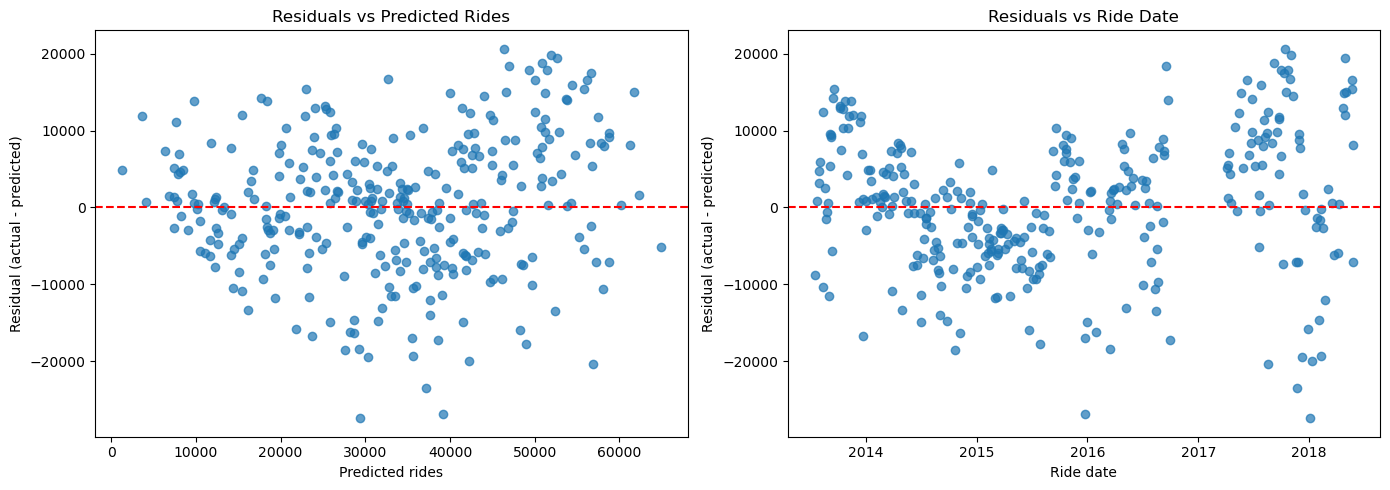

In [8]:
test_results = X_test.copy()
test_results['ride_date'] = df.loc[X_test.index, 'ride_date']
test_results['actual'] = y_test
test_results['predicted'] = test_pred
test_results['residual'] = test_results['actual'] - test_results['predicted']
test_results = test_results.sort_values('ride_date')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test_results['predicted'], test_results['residual'], alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted Rides')
axes[0].set_xlabel('Predicted rides')
axes[0].set_ylabel('Residual (actual - predicted)')

axes[1].scatter(test_results['ride_date'], test_results['residual'], alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Ride Date')
axes[1].set_xlabel('Ride date')
axes[1].set_ylabel('Residual (actual - predicted)')

plt.tight_layout()
plt.show()

### M5 answer
A residual is the difference between the actual number of rides and the predicted number of rides. A positive residual means the model predicted too few rides. A negative residual means the model predicted too many rides.

The residual plots are not completely random. There are some large positive and negative errors, and the residuals show structure over time. This suggests that the simple linear time trend does not capture every time-related change in ridership. The model may also be missing factors such as holidays, special events, changes in station availability, or unusual weather.

## M6 — Improve One Thing

### Question / Description
Make one improvement based on the model diagnosis, refit the model, and compare test R² before and after. Keep both results visible even if the change does not help.

### My change
I added `temp_f_squared`. This helps linear regression model a curved temperature relationship instead of assuming that every additional degree has exactly the same effect on ridership.

In [9]:
improved_features = core_features.copy()
improved_features.append('temp_f_squared')

X_improved = df[improved_features].copy()
y_improved = df[target_col].copy()

X_improved_train, X_improved_test, y_improved_train, y_improved_test = train_test_split(
    X_improved, y_improved, test_size=0.20, random_state=42
)

improved_model = LinearRegression()
improved_model.fit(X_improved_train, y_improved_train)

improved_test_pred = improved_model.predict(X_improved_test)
improved_test_r2 = r2_score(y_improved_test, improved_test_pred)
improved_test_mae = mean_absolute_error(y_improved_test, improved_test_pred)
improved_test_rmse = np.sqrt(mean_squared_error(y_improved_test, improved_test_pred))

comparison_df = pd.DataFrame({
    'model': ['Core model', 'Improved model: temp_f_squared'],
    'test_r2': [test_r2, improved_test_r2],
    'test_mae': [test_mae, improved_test_mae],
    'test_rmse': [test_rmse, improved_test_rmse]
})

comparison_df

,model,test_r2,test_mae,test_rmse
0,Core model,0.750472,6987.141196,8875.799568
1,Improved model: temp_f_squared,0.761348,6748.938539,8680.222351


### M6 answer
Adding `temp_f_squared` improved all three test metrics. The core model had a test R² of **0.750472**, a test MAE of **6,987.14 rides**, and a test RMSE of **8,875.80 rides**. The improved model had a test R² of **0.761348**, a test MAE of **6,748.94 rides**, and a test RMSE of **8,680.22 rides**.

The improved model explains about **76.1%** of the variation in daily ridership, compared with about **75.0%** for the core model. Its typical daily error decreased by about **238 rides**, and its RMSE decreased by about **196 rides**. This is a modest but consistent improvement, so I would keep the squared-temperature feature.